In [5]:
import sys
sys.path.append('/home/azureuser/prathyusha/Kearney/prathyusha')

from utils import *
from pyspark.sql.functions import *
from pyspark.sql.window import *

spark = instantiate_spark_sedona("10g")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/12 04:47:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Session and SedonaContext have been successfully initiated.


In [3]:
final_df = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/thailand_quadkeys/Quadkey_pop_hh_estimated_updated")
final_df.printSchema()

root
 |-- quadkey: string (nullable = true)
 |-- adm1_name: string (nullable = true)
 |-- Pop_nso_to_hdx_ratio: double (nullable = true)
 |-- hdx_Quadkey_Pop: double (nullable = true)
 |-- nso_adjusted_population: double (nullable = true)
 |-- sum_floor_area_sqm: double (nullable = true)
 |-- Qk_pop_to_hh_sampled: double (nullable = true)
 |-- Qk_estimated_hh: double (nullable = true)



In [16]:
def quadkey_to_wkt_geometry(qk):
    import mercantile
    from shapely.geometry import shape
    if not qk:
        return None
    try:

        tile_feature = mercantile.feature(mercantile.quadkey_to_tile(qk))
        return shape(tile_feature['geometry']).wkt
    except:
        return None

quadkey_to_wkt_udf = udf(quadkey_to_wkt_geometry, StringType())

In [17]:
bangkok = final_df.filter(col('adm1_name') == 'bangkok').orderBy(col('Qk_estimated_hh').desc())
bangkok = bangkok.withColumn("quadkey_geometry", quadkey_to_wkt_udf(col('quadkey')))
bangkok.show()

+----------------+---------+--------------------+-----------------+-----------------------+------------------+--------------------+---------------+--------------------+
|         quadkey|adm1_name|Pop_nso_to_hdx_ratio|  hdx_Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|Qk_pop_to_hh_sampled|Qk_estimated_hh|    quadkey_geometry|
+----------------+---------+--------------------+-----------------+-----------------------+------------------+--------------------+---------------+--------------------+
|1322033101311230|  bangkok|  0.9269929581391236|9945.886838999952|      9219.767062201543| 729756.8898057863|   2.026651598923461|         4549.0|POLYGON ((100.513...|
|1322033101311303|  bangkok|  0.9269929581391236|9469.540323999954|      8778.197197162433| 923403.8414772258|  1.9728306239231554|         4450.0|POLYGON ((100.530...|
|1322033101311312|  bangkok|  0.9269929581391236|9054.378774999957|      8393.345364749304|1051890.1249666824|  1.9447574825771132|         4316.0|POLYGON 

In [19]:
bangkok.toPandas().to_csv('Bangkok.csv',index=False)

In [18]:
bangkok.orderBy(col('Qk_pop_to_hh_sampled').desc()).show()

+----------------+---------+--------------------+---------------+-----------------------+------------------+--------------------+---------------+--------------------+
|         quadkey|adm1_name|Pop_nso_to_hdx_ratio|hdx_Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|Qk_pop_to_hh_sampled|Qk_estimated_hh|    quadkey_geometry|
+----------------+---------+--------------------+---------------+-----------------------+------------------+--------------------+---------------+--------------------+
|1322031332332233|  bangkok|  0.9269929581391236|      28.543044|     26.459200791855164|23.307516591070446|   3.525586783452892|            8.0|POLYGON ((100.827...|
|1322033111022001|  bangkok|  0.9269929581391236|      28.543044|     26.459200791855164| 27.01608895060156|   3.524476744820132|            8.0|POLYGON ((100.903...|
|1322033103101212|  bangkok|  0.9269929581391236|      33.300218|     30.869067590497693|31.375726696448588|  3.5104248124725066|            9.0|POLYGON ((100.426...

In [21]:
bangkok.filter(col('quadkey') == '1322033101311102').show()

+----------------+---------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+--------------------+
|         quadkey|adm1_name|Pop_nso_to_hdx_ratio|   hdx_Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|Qk_pop_to_hh_sampled|Qk_estimated_hh|    quadkey_geometry|
+----------------+---------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+--------------------+
|1322033101311102|  bangkok|  0.9269929581391236|4870.6470399999935|       4515.05550766116| 628998.1095368519|   2.047551829681769|         2205.0|POLYGON ((100.524...|
+----------------+---------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+--------------------+



In [26]:
pop_quadtile = spark.read.parquet('abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Population_filtered/thailand_population_quadkey_indexed.parquet')
pop_quadtile.filter(col('qk16') == '1322033110022122').toPandas().to_csv('qk_1322033110022122_pop.csv', index=False)
pop_quadtile.filter(col('qk16') == '1322033101132333').toPandas().to_csv('qk_1322033101132333_pop.csv', index=False)

In [3]:
residential_preds = spark.read.parquet('/home/azureuser/prathyusha/Kearney/vishaal/data_eda/data/thailand_buildings_residential_classified.parquet')
residential_preds.show()

+----+--------------------+------------+-------------------+--------------------+----------------+----------------+------+----------+------------------+------------------+-------------------+----------------+--------------+---------------------+-----------------------+------------------+-----------------------------+
|  id|       geom_source_1|height_tiles|        province_en|         district_en|       tambon_en|         quadkey|floors|households| building_area_sqm|  total_floor_area|building_complexity|subtype_overture|is_residential|predicted_residential|probability_residential|        confidence|predicted_residential_updated|
+----+--------------------+------------+-------------------+--------------------+----------------+----------------+------+----------+------------------+------------------+-------------------+----------------+--------------+---------------------+-----------------------+------------------+-----------------------------+
|  17|MULTIPOLYGON (((1...|        NULL|   

In [20]:
residential_preds.filter(col('province_en') == 'Bangkok').select(col('district_en'), 'tambon_en').distinct().count()

169

In [16]:
residential_preds_sample = residential_preds.filter(col('tambon_en') == 'Phraborom Maharatchawang')
residential_preds_sample.show()

+-------+--------------------+------------+-----------+-----------+--------------------+----------------+------+----------+------------------+------------------+-------------------+----------------+--------------+---------------------+-----------------------+------------------+-----------------------------+
|     id|       geom_source_1|height_tiles|province_en|district_en|           tambon_en|         quadkey|floors|households| building_area_sqm|  total_floor_area|building_complexity|subtype_overture|is_residential|predicted_residential|probability_residential|        confidence|predicted_residential_updated|
+-------+--------------------+------------+-----------+-----------+--------------------+----------------+------+----------+------------------+------------------+-------------------+----------------+--------------+---------------------+-----------------------+------------------+-----------------------------+
|4908261|POLYGON ((100.489...|         H:4|    Bangkok|Phra Nakhon|Phrabo

In [17]:
residential_preds_sample.toPandas().to_csv('Phraborom Maharatchawang_buildings.csv', index=False)

In [12]:
residential_preds.filter(col('tambon_en') == 'Phraborom Maharatchawang').select(sum('predicted_residential_updated')).show()

+----------------------------------+
|sum(predicted_residential_updated)|
+----------------------------------+
|                                 5|
+----------------------------------+



In [15]:
residential_preds.filter(col('tambon_en') == 'Phraborom Maharatchawang').select(count('predicted_residential_updated')).show()

+------------------------------------+
|count(predicted_residential_updated)|
+------------------------------------+
|                                1389|
+------------------------------------+



In [7]:
residential_buil = residential_preds.groupBy('quadkey').agg(sum('predicted_residential_updated').alias('Residential_Buildings_count'), count('predicted_residential_updated').alias('Residential_Buildings_count')).show()
residential_buil.show()


+----------------+---------------------------+---------------------------+
|         quadkey|Residential_Buildings_count|Residential_Buildings_count|
+----------------+---------------------------+---------------------------+
|1322031122231100|                          1|                        107|
|1322013320011323|                          0|                          7|
|1322011302231332|                          0|                         36|
|1322013320120002|                         32|                        199|
|1322213100300022|                          0|                         96|
|1322033100300220|                          0|                         14|
|1322011300320230|                          2|                        158|
|1322033100122120|                         55|                         91|
|1322011322300303|                          1|                         62|
|1322213120120121|                          0|                        114|
|1322033120122310|       

AttributeError: 'NoneType' object has no attribute 'show'

In [48]:
buildings_df.dtypes

[('id', 'bigint'),
 ('geom_source_1', 'string'),
 ('height_tiles', 'string'),
 ('height_overture', 'double'),
 ('num_floors_overture', 'int'),
 ('subtype_overture', 'string'),
 ('province_en', 'string'),
 ('district_en', 'string'),
 ('tambon_en', 'string'),
 ('tambon_code', 'string'),
 ('gh6', 'string'),
 ('LU_DES_EN', 'string'),
 ('Shape_Area', 'double'),
 ('RAI', 'double'),
 ('landuse_present', 'boolean'),
 ('centroid_lon', 'double'),
 ('centroid_lat', 'double'),
 ('quadkey', 'string')]

In [50]:
buildings_df = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Gee_Buildings/buildings_full_dataset_with_quadkey_with_floor_area.parquet")
buildings_df.show()

+-------+--------------------+------------+-----------+-----------+------------+----------------+------+----------+------------------+------------------+
|     id|       geom_source_1|height_tiles|province_en|district_en|   tambon_en|         quadkey|floors|households| building_area_sqm|  total_floor_area|
+-------+--------------------+------------+-----------+-----------+------------+----------------+------+----------+------------------+------------------+
|4664436|POLYGON ((100.469...|        NULL|    Bangkok|Bangkok Noi|Arun Ammarin|1322033101132021|   3.0|         6|29.148552232041453| 87.44565669612436|
|4688642|POLYGON ((100.471...|    HBET:1-5|    Bangkok|Bangkok Noi|Arun Ammarin|1322033101132032|   3.0|         6|168.23701361735215|504.71104085205644|
|4699077|POLYGON ((100.472...|    HBET:1-5|    Bangkok|Bangkok Noi|Arun Ammarin|1322033101132032|   3.0|         6|  70.4121949765422| 211.2365849296266|
|4760579|POLYGON ((100.476...|    HBET:1-5|    Bangkok|Bangkok Noi|Arun Amma

In [53]:
buildings_df = spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/Gee_Buildings/buildings_full_dataset_with_quadkey_with_floor_area.parquet")
buildings_quadkey_level = buildings_df.groupBy('quadkey').agg(count('*').alias('buil_count'), sum('floors').alias('total_floors'), avg('floors').alias('floors_per_buil'))
buildings_quadkey_level 

DataFrame[quadkey: string, buil_count: bigint, total_floors: double, floors_per_buil: double]

In [57]:
buildings_quadkey_level.agg(max('total_floors')).show()

+-----------------+
|max(total_floors)|
+-----------------+
|           4596.0|
+-----------------+



In [45]:
buildings_df_qk1322033110110102 = buildings_df.filter(col("quadkey") == '1322033110110102')
buildings_df_qk1322033110110102.toPandas().to_csv('buildings_df_qk1322033110110102.csv', index=False)

In [58]:
final_df= spark.read.parquet("abfss://propheus-data-science@propheusdatabay.dfs.core.windows.net/Thailand/thailand_quadkeys/Quadkey_pop_hh_estimated_updated")
final_df = final_df.join(
    buildings_quadkey_level,
    on = 'quadkey',
    how = 'inner'
)
final_df.show()

+----------------+----------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+----------+------------+---------------+
|         quadkey| adm1_name|Pop_nso_to_hdx_ratio|   hdx_Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|Qk_pop_to_hh_sampled|Qk_estimated_hh|buil_count|total_floors|floors_per_buil|
+----------------+----------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+----------+------------+---------------+
|1322010330330112|maehongson|   1.156384169474568|         3.3361215|       3.85783809004375|120.31849027728747|  3.0752889070291864|            1.0|         4|         4.0|            1.0|
|1322010331201320|maehongson|   1.156384169474568|1.8587143333333334|      2.149387830642142|17.154244963232237|   3.665291787562955|            1.0|         1|         1.0|            1.0|
|1322010331201323|maehongson|   1.156384169474568|

In [59]:
final_df = final_df.withColumn("Area_per_HH", col('sum_floor_area_sqm')/col('Qk_estimated_hh'))
final_df = final_df.filter(col('adm1_name') == 'bangkok')
final_df = final_df.withColumn("quadkey_geometry", quadkey_to_wkt_udf(col('quadkey')))
final_df = final_df.orderBy(col('Area_per_HH'))
final_df.show()

+----------------+---------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+----------+------------+---------------+------------------+--------------------+
|         quadkey|adm1_name|Pop_nso_to_hdx_ratio|   hdx_Quadkey_Pop|nso_adjusted_population|sum_floor_area_sqm|Qk_pop_to_hh_sampled|Qk_estimated_hh|buil_count|total_floors|floors_per_buil|       Area_per_HH|    quadkey_geometry|
+----------------+---------+--------------------+------------------+-----------------------+------------------+--------------------+---------------+----------+------------+---------------+------------------+--------------------+
|1322031332332233|  bangkok|  0.9269929581391236|         28.543044|     26.459200791855164|23.307516591070446|   3.525586783452892|            8.0|         1|         1.0|            1.0|2.9134395738838057|POLYGON ((100.827...|
|1322033111000200|  bangkok|  0.9269929581391236|         38.057392|      35.2789343

In [60]:
final_df.count()

4432

In [61]:
final_df.select(sum('Qk_estimated_hh')).show()

+--------------------+
|sum(Qk_estimated_hh)|
+--------------------+
|           3675533.0|
+--------------------+



In [62]:
final_df_pd = final_df.toPandas()
plottable = final_df_pd[final_df_pd['Area_per_HH'] < 500]
plottable

,quadkey,adm1_name,Pop_nso_to_hdx_ratio,hdx_Quadkey_Pop,nso_adjusted_population,sum_floor_area_sqm,Qk_pop_to_hh_sampled,Qk_estimated_hh,buil_count,total_floors,floors_per_buil,Area_per_HH,quadkey_geometry
0,1322031332332233,bangkok,0.926993,28.543044,26.459201,2.330752e+01,3.525587,8.0,1,1.0,1.000000,2.913440,POLYGON ((100.8270263671875 13.923403897723341...
1,1322033111000200,bangkok,0.926993,38.057392,35.278934,3.245552e+01,3.497356,10.0,1,1.0,1.000000,3.245552,"POLYGON ((100.8984375 13.896743534015751, 100...."
2,1322033111022001,bangkok,0.926993,28.543044,26.459201,2.701609e+01,3.524477,8.0,1,1.0,1.000000,3.377011,POLYGON ((100.9039306640625 13.790071437194845...
3,1322033103101212,bangkok,0.926993,33.300218,30.869068,3.137573e+01,3.510425,9.0,1,2.0,2.000000,3.486192,"POLYGON ((100.426025390625 13.549881446917132,..."
4,1322033103101122,bangkok,0.926993,38.057392,35.278934,3.534362e+01,3.494063,10.0,1,2.0,2.000000,3.534362,"POLYGON ((100.43701171875 13.560561745081424, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4157,1322033101033302,bangkok,0.926993,788.318685,730.765870,1.310761e+05,2.760512,265.0,349,1002.0,2.871060,494.626762,"POLYGON ((100.34912109375 13.763395779624453, ..."
4158,1322033101122121,bangkok,0.926993,1175.311494,1089.505479,2.055278e+05,2.637542,413.0,404,1212.0,3.000000,497.646036,POLYGON ((100.3985595703125 13.779401539612378...
4159,1322033101311203,bangkok,0.926993,4669.771530,4328.845324,1.120257e+06,1.924439,2249.0,265,885.0,3.339623,498.113299,POLYGON ((100.5084228515625 13.720708401412061...
4160,1322033101302312,bangkok,0.926993,1067.474254,989.541116,1.839511e+05,2.679333,369.0,393,1179.0,3.000000,498.512561,"POLYGON ((100.404052734375 13.678013256725485,..."


<Axes: >

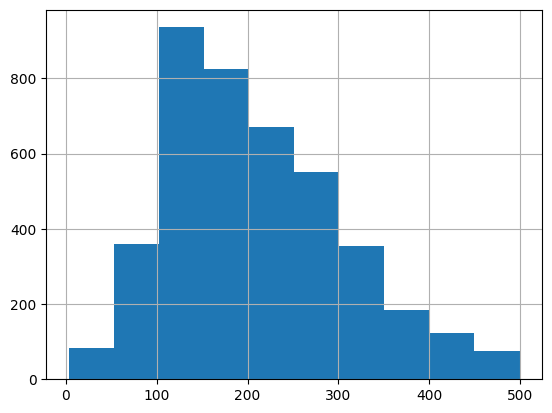

In [63]:
plottable['Area_per_HH'].hist()

In [64]:
anamolies = final_df_pd[(final_df_pd['Area_per_HH'] <= 50) | (final_df_pd['Area_per_HH'] > 400)]
anamolies.to_csv('anamolies_check.csv', index=False)


In [67]:
anamolies = final_df_pd[(final_df_pd['Area_per_HH'] <= 100)]
anamolies.to_csv('anamolies_lower_check.csv', index=False)

anamolies = final_df_pd[(final_df_pd['Area_per_HH'] >= 400)]
anamolies.to_csv('anamolies_higher_check.csv', index=False)

In [66]:
anamolies.dtypes

quadkey                     object
adm1_name                   object
Pop_nso_to_hdx_ratio       float64
hdx_Quadkey_Pop            float64
nso_adjusted_population    float64
sum_floor_area_sqm         float64
Qk_pop_to_hh_sampled       float64
Qk_estimated_hh            float64
buil_count                   int64
total_floors               float64
floors_per_buil            float64
Area_per_HH                float64
quadkey_geometry            object
dtype: object

/tmp/ipykernel_2571387/4095585263.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  plottable_anamolies = anamolies[final_df_pd['Area_per_HH'] < 500]


<Axes: >

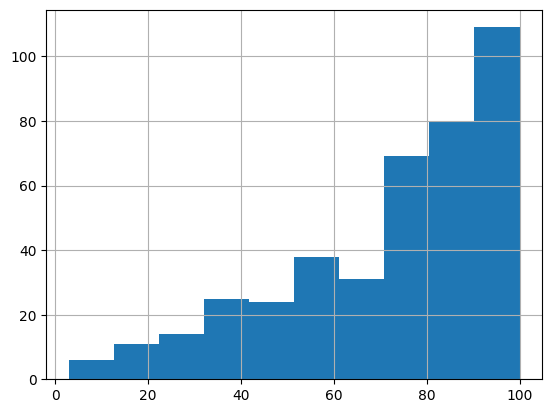

In [46]:

plottable_anamolies = anamolies[final_df_pd['Area_per_HH'] < 500]
plottable_anamolies['Area_per_HH'].hist()

In [47]:
anamolies.count()

quadkey                    407
adm1_name                  407
Pop_nso_to_hdx_ratio       407
hdx_Quadkey_Pop            407
nso_adjusted_population    407
sum_floor_area_sqm         407
Qk_pop_to_hh_sampled       407
Qk_estimated_hh            407
buil_count                 407
Area_per_HH                407
quadkey_geometry           407
dtype: int64

In [69]:
final_df_pd.dtypes

quadkey                     object
adm1_name                   object
Pop_nso_to_hdx_ratio       float64
hdx_Quadkey_Pop            float64
nso_adjusted_population    float64
sum_floor_area_sqm         float64
Qk_pop_to_hh_sampled       float64
Qk_estimated_hh            float64
buil_count                   int64
total_floors               float64
floors_per_buil            float64
Area_per_HH                float64
quadkey_geometry            object
dtype: object

In [70]:
high_hh = final_df_pd[(final_df_pd['buil_count'] <= final_df_pd['Qk_estimated_hh'])]
high_hh.count()


quadkey                    3789
adm1_name                  3789
Pop_nso_to_hdx_ratio       3789
hdx_Quadkey_Pop            3789
nso_adjusted_population    3789
sum_floor_area_sqm         3789
Qk_pop_to_hh_sampled       3789
Qk_estimated_hh            3789
buil_count                 3789
total_floors               3789
floors_per_buil            3789
Area_per_HH                3789
quadkey_geometry           3789
dtype: int64

<Axes: >

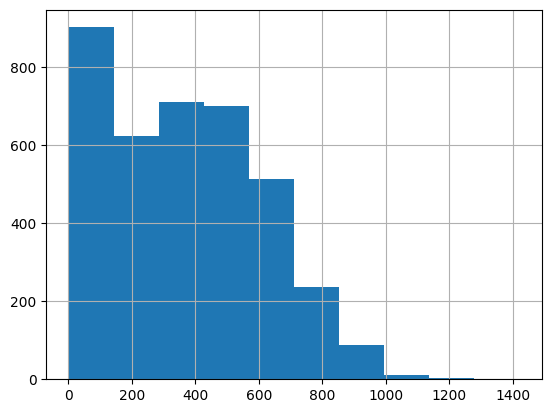

In [71]:
high_hh['buil_count'].hist()

## Matching HH counts from residential model to the match the number